# Ensemble validation

The 5 parameter sets calculkated in Calibration_HBV.ipynb will be used for a validation period, in which the log NSE will be calculated, a mean will be calculated and total low flow days during the navigation season.

The structure of this notebook is as follows:

### 1. Startup
### 2. Model Setup
### 3. Running model
### 4. LNSE calculation
### 5. Display results
### 6. Lowflow calculation
### 7. Cumsum distribution

## 1. Startup

In [2]:
# General python
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
from scipy.interpolate import interp1d

# Niceties
from rich import print

In [3]:
# General eWaterCycle
import ewatercycle
import ewatercycle.models
import ewatercycle.forcing

In [4]:
# Defining things

basin_size = 132572
q_critical = 500

In [5]:
# Choosing time period

# experiment_start_date = "2019-01-01T00:00:00Z"
# experiment_end_date = "2024-12-31T00:00:00Z"

start_year = 1995
end_year = 2014

validation_start = f"{start_year}-01-01T00:00:00Z"
validation_end = f"{end_year}-12-31T00:00:00Z"

# Choose CMIP Scenario: 
Scenario = "historical"    # Options: historical, ssp119, ssp126, ssp245, ssp,370, ssp585

In [6]:
# # Create pathways for ERA 5 forcings

# forcing_path_ERA5 = Path.home() / "BEP-maxime" / "Workyard" / "forcings" / f"ERA5-{start_year}-{end_year}"

# forcing_path_CMIP = Path.home() / "BEP-maxime" / "Workyard" / "forcings" / "CMIP6" / Scenario / f"CMIP6-{start_year}-{end_year}"

# forcing_path_QDM = Path.home() / "BEP-maxime" / "Workyard" / "forcings" / "CMIP6" / Scenario / f"CMIP6-QDM-{start_year}-{end_year}"

# discharge_file = Path.home() / "BEP-maxime" / "Workyard" / "07DA001_discharge_daily_withoutmissing.csv"

# shape_file = Path.home() / "BEP-maxime" / "Workyard" / "Shapefiles" / "07DA001_basin.shp"

# hbv_config = Path.home() / "BEP-maxime" / "Workyard" / "hbv_config"
# hbv_config.mkdir(parents=True, exist_ok=True)

In [7]:
# # Create pathways for forcings

forcing_path_ERA5 = Path.home() / "BEP-maxime" / "book" / "thesis_projects" / "BSc" / "2026_Q4_MaximedeBekker_CEG" /  "Workyard" / "forcings" / "ERA5" / "ERA5-1999-2019"

forcing_path_CMIP = Path.home() / "BEP-maxime" / "book" / "thesis_projects" / "BSc" / "2026_Q4_MaximedeBekker_CEG" / "Workyard" / "forcings" / "CMIP6" / Scenario / f"CMIP6-{start_year}-{end_year}"

forcing_path_QDM = Path.home() / "BEP-maxime" / "book" / "thesis_projects" / "BSc" / "2026_Q4_MaximedeBekker_CEG" / "Workyard" / "forcings" / "CMIP6" / Scenario / f"CMIP6-QDM-{start_year}-{end_year}"

discharge_file = Path.home() / "BEP-maxime" / "book" / "thesis_projects" / "BSc" / "2026_Q4_MaximedeBekker_CEG" /  "Workyard" / "07DA001_discharge_daily_withoutmissing.csv"

shape_file = Path.home() / "BEP-maxime" / "book" / "thesis_projects" / "BSc" / "2026_Q4_MaximedeBekker_CEG" /  "Workyard" / "Shapefiles" / "07DA001_basin.shp"

hbv_config = Path.home() / "BEP-maxime" / "book" / "thesis_projects" / "BSc" / "2026_Q4_MaximedeBekker_CEG" /  "Workyard" / "hbv_config"
hbv_config.mkdir(parents=True, exist_ok=True)

In [124]:
# Load CSV discharge 07DA001

q_obs = pd.read_csv(discharge_file, skiprows=1)
q_obs = q_obs[["Date", "Value"]].copy()
q_obs["Date"] = pd.to_datetime(q_obs["Date"])
q_obs = q_obs.rename(columns={"Value": "discharge_m3s"})

q_obs.head()

,Date,discharge_m3s
0,1957-10-01,467.0
1,1957-10-02,467.0
2,1957-10-03,467.0
3,1957-10-04,476.0
4,1957-10-05,487.0


In [125]:
# Define time period
validation_start_date = pd.to_datetime(validation_start.replace("Z", ""))
validation_end_date = pd.to_datetime(validation_end.replace("Z", ""))

# Skip 1 year for filling storages
evaluation_start = pd.to_datetime(f"{validation_start_date.year + 1}-01-01")

# Align q_obs to relevant dates
q_obs = q_obs[(q_obs["Date"] >= validation_start_date) & (q_obs["Date"] <= validation_end_date)]
observed_output = pd.Series(data=q_obs["discharge_m3s"].to_numpy(), name="Observed discharge", index=q_obs["Date"])

In [126]:
observed_output.head()

Date
1995-01-01    197.0
1995-01-02    196.0
1995-01-03    194.0
1995-01-04    191.0
1995-01-05    186.0
Name: Observed discharge, dtype: float64

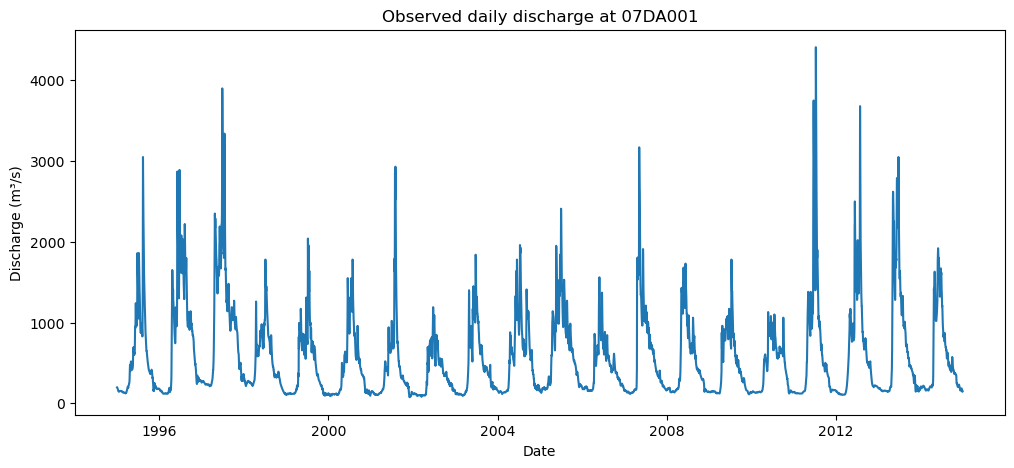

In [11]:
# Plot q_obs

plt.figure(figsize=(12, 5))
plt.plot(q_obs["Date"], q_obs["discharge_m3s"])

plt.xlabel("Date")
plt.ylabel("Discharge (m³/s)")
plt.title("Observed daily discharge at 07DA001")

plt.show()

### Generate/Load CMIP6 data

In [12]:
# Generate data
# CMIP_dataset = {'dataset': 'MPI-ESM1-2-HR', 'project': 'CMIP6', 'grid' : 'gn', 'exp': 'historical', 'ensemble': 'r1i1p1f1'}

# CMIP_forcing = ewatercycle.forcing.sources["LumpedMakkinkForcing"].generate(
#     dataset=CMIP_dataset,
#    start_time=validation_start,
#    end_time=validation_end,
#    shape=shape_file,
# )
# CMIP_forcing_QDM = ewatercycle.forcing.sources["LumpedMakkinkForcing"].generate(
#     dataset=CMIP_dataset,
#    start_time=validation_start,
#    end_time=validation_end,
#    shape=shape_file,
# )

# Load data

ERA5_forcing = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(directory=forcing_path_ERA5)

CMIP_forcing = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(directory=forcing_path_CMIP)

# QDM_forcing = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(directory=forcing_path_QDM)

print(CMIP_forcing)

LumpedMakkinkForcing(
    start_time='1995-01-01T00:00:00Z',
    end_time='2014-12-31T00:00:00Z',
    directory=PosixPath('/home/maxime/BEP-maxime/book/thesis_projects/BSc/2026_Q4_MaximedeBekker_CEG/Workyard/forci
ngs/CMIP6/historical/CMIP6-1995-2014'),
    shape=PosixPath('/home/maxime/BEP-maxime/Workyard/Shapefiles/07DA001_basin.shp'),
    filenames={
        'evspsblpot': 'combined_CMIP6_1995_2014_evspsblpot.nc',
        'pr': 'combined_CMIP6_1995_2014_pr.nc',
        'rsds': 'combined_CMIP6_1995_2014_rsds.nc',
        'tas': 'combined_CMIP6_1995_2014_tas.nc'
    }
)

### Load parameter sets & initial storages

In [13]:
# Load calibration constants

# par_0 = [4.45787, 0.42307, 201.57602, 2.36497, 0.26755, 8.62964, 0.083568, 0.0037073, 0.29645]
# par_0 = [2.79874, 0.49211, 255.96478, 1.782968, 0.503199, 6.095956, 0.33279, 0.10539, 0.63857]
# par_0 = [6.279135, 0.4808243, 174.127749, 1.9527195, 0.3305087, 6.19919, 0.0768362, 0.004366398, 0.4076606]         # 0.725 val, 0.x cal - Fav run 2
# par_0 = [6.28908, 0.423917, 173.56627, 1.63144, 0.402586, 6.56151, 0.0456809, 0.00313744, 0.516696]                 # 0.702 val, 0.x cal
# par_0 = [6.4919, 0.386877, 221.78625, 1.388269, 0.276453, 4.9870704, 0.04126777, 0.05640195, 1.148877]              # 0.668 val, 0.x cal
# par_0 = [7.502398, 0.38028, 194.1899, 1.680197, 0.47956, 4.8566806, 0.041745354, 0.02833896, 1.051862]              # 0.677 val, 0.x cal
# par_0 = [5.5464, 0.46496, 187.8548, 1.82803, 0.440628, 6.29496, 0.062766, 0.033095, 0.80392]                        # 0.781 val, 0.776 cal
# par_0 = [6.16512, 0.4369419, 151.2515900, 1.727835, 0.3771705, 6.19265974, 0.06959136, 0.001310818, 0.8130732]      # 0.664 val, 0.791 cal
# par_0 = [5.7107, 0.441634, 172.81305, 1.87367, 0.588802, 5.498147, 0.060305, 0.019666, 1.2011814]                    # x val, 0.73 cal         Start of 5+ months exclusion
# par_0 = [7.35776, 0.432509, 192.67085, 1.66088, 0.289296, 5.323766, 0.037268, 0.004399, 1.146504]                    # 0.82 val, 0.818 cal - Fav run 1      
# par_0 = [7.23868, 0.47495, 181.82012, 1.8232, 0.4884032, 5.546412, 0.0449439, 0.00231717, 1.25052]                    #  val,  0.77 cal    
# par_0 = [7.9355, 0.4593, 219.6962, 1.72624, 0.26391, 5.810765, 0.04804, 0.0155065, 0.76857]                           # 0.78 val, 0.71 cal - potential inclusion

par_ensemble = [
    [6.279135, 0.4808243, 174.127749, 1.9527195, 0.3305087, 6.19919, 0.0768362, 0.004366398, 0.4076606],
    [7.35776, 0.432509, 192.67085, 1.66088, 0.289296, 5.323766, 0.037268, 0.004399, 1.146504],
    [7.9355, 0.4593, 219.6962, 1.72624, 0.26391, 5.810765, 0.04804, 0.0155065, 0.76857],
    [5.5464, 0.46496, 187.8548, 1.82803, 0.440628, 6.29496, 0.062766, 0.033095, 0.80392],
   [7.23868, 0.47495, 181.82012, 1.8232, 0.4884032, 5.546412, 0.0449439, 0.00231717, 1.25052]
]


par_names = ["Imax",         # Maximum interception storage
               "Ce",         # Evaporation correction factor
               "Sumax",      # Maximum soil moisture storage
               "Beta",       # Soil runoff parameter
               "Pmax",       # Maximum percolation rate
               "Tlag",       # Time lag
               "Kf",         # Fast reservoir recession coefficient
               "Ks",         # Slow reservoir recession coefficient
               "FM"          # Snowmelt factor
               ]

# Initial: par_0 = [5.085, 0.55, 100.373, 1.612, 0.545, 3.801, 0.196, 0.00, 0.185]

In [14]:
# Storages

#               Si,  Su, Sf, Ss, Sp
s_0 = np.array([0,  100,  0,  5,  0])

## 2. Model setup

In [15]:
def run_hbv(parameters, initial_storages, forcing):

    # Creating model object
    model = ewatercycle.models.HBV(forcing=forcing)

    # Creating config file
    config_file, _ = model.setup(
        parameters=parameters,
        initial_storages=initial_storages,
        cfg_dir=hbv_config
    )

    # Initialising model
    model.initialize(config_file)

    # Define & update outputs
    Q_m = []
    time = []

    while model.time < model.end_time:
        model.update()
        Q_m.append(model.get_value("Q")[0])
        time.append(pd.Timestamp(model.time_as_datetime))

    model.finalize()

    # Convert mm/day to m3/s
    model_output_mmday = pd.Series(
        data=Q_m,
        index=time,
        name="Modelled discharge"
    )

    model_output_m3s = model_output_mmday * basin_size * 1000 / 86400

    return model_output_m3s

## 3. Running model

In [16]:
def run_hbv_ensemble(par_ensemble, initial_storages, forcing):

    # Define amount of parameter sets
    N = len(par_ensemble)
    
    # Create dataframe to append data to & add column for observed data
    ensemble_data = pd.DataFrame()

    for i in range(N):

        print(f"Running parameter set {i+1}/{N}")

        # Run HBV model for the parameter sets 
        simulated = run_hbv(
            parameters=par_ensemble[i],
            initial_storages=initial_storages,
            forcing=forcing
        )

        # Filter data by day only, not by day & time to prevent alignment issues
        simulated_daily = simulated

        simulated_daily.index = pd.to_datetime(simulated_daily.index).tz_localize(None).normalize()
        simulated_daily.name = f"Set {i+1}"
         
        # Append new column for every parameter set results
        ensemble_data[f"Set {i+1}"] = simulated

    # Filter observed data by day
    observed_daily = observed_output
    observed_daily.index = pd.to_datetime(observed_daily.index).tz_localize(None).normalize()

    # Add mean of all sets
    ensemble_data["Mean"] = ensemble_data.mean(axis=1)
    ensemble_data['Observed discharge'] = observed_daily

    return ensemble_data

In [28]:
ensemble_data_ERA5 = run_hbv_ensemble(
    par_ensemble=par_ensemble,
    initial_storages=s_0,
    forcing=ERA5_forcing
)

ensemble_data_CMIP = run_hbv_ensemble(
    par_ensemble=par_ensemble,
    initial_storages=s_0,
    forcing=CMIP_forcing
)

# ensemble_data_QDM = run_hbv_ensemble(
#     par_ensemble=par_ensemble,
#     initial_storages=s_0,
#     forcing=QDM_forcing
# )

Running parameter set 1/5

Running parameter set 2/5

Running parameter set 3/5

Running parameter set 4/5

Running parameter set 5/5

...

Running parameter set 2/5

Running parameter set 3/5

Running parameter set 4/5

Running parameter set 5/5

,Set 1,Set 2,Set 3,Set 4,Set 5,Mean,Observed discharge
1999-01-02,0.0,0.0,0.0,0.0,0.0,0.0,103.0
1999-01-03,0.0,0.0,0.0,0.0,0.0,0.0,101.0
1999-01-04,0.0,0.0,0.0,0.0,0.0,0.0,103.0
1999-01-05,0.0,0.0,0.0,0.0,0.0,0.0,105.0
1999-01-06,0.0,0.0,0.0,0.0,0.0,0.0,108.0


In [33]:
ensemble_data_ERA5.head()
# ensemble_data_CMIP.head()

,Set 1,Set 2,Set 3,Set 4,Set 5,Mean,Observed discharge
1999-01-02,0.0,0.0,0.0,0.0,0.0,0.0,103.0
1999-01-03,0.0,0.0,0.0,0.0,0.0,0.0,101.0
1999-01-04,0.0,0.0,0.0,0.0,0.0,0.0,103.0
1999-01-05,0.0,0.0,0.0,0.0,0.0,0.0,105.0
1999-01-06,0.0,0.0,0.0,0.0,0.0,0.0,108.0


## 4. LNSE Calculation

In [18]:
# Calculate log NSE

def LNSE(sim, obs):
    
    sim = sim.to_numpy()
    obs = obs.to_numpy()

    # Avoid log(0)
    eps = 0.00000000001

    log_sim = np.log(sim + eps)
    log_obs = np.log(obs + eps)

    return 1 - np.sum((log_obs - log_sim) ** 2) / np.sum((log_obs - np.mean(log_obs)) ** 2)

In [19]:
# Call log NSE for relevant timeperiod

def lnse_ensemble(ensemble_data, lnse_start, lnse_end):

    # Select evaluation period - skip first year for storages to fill
    combined_data = ensemble_data[
        (ensemble_data.index >= lnse_start) &
        (ensemble_data.index <= lnse_end)
    ].dropna()

    # Exclude winter months
    combined_data = combined_data[
        ~combined_data.index.month.isin([12, 1, 2, 3, 4])
    ]

    lnse_results = []

    # Calculate LNSE for all sets
    for i in range(len(par_ensemble)):
        lnse_value = LNSE(
            combined_data[f"Set {i+1}"],
            combined_data["Observed discharge"]
        )

        # Append LNSE
        lnse_results.append({
            "Set": f"Set {i+1}",
            "LNSE": lnse_value
        })

    # Calculate LNSE of ensemble mean
    mean_lnse = LNSE(
        combined_data["Mean"],
        combined_data["Observed discharge"]
    )

    # Append LNSE
    lnse_results.append({
        "Set": "Ensemble mean",
        "LNSE": mean_lnse
    })

    lnse_results = pd.DataFrame(lnse_results)

    return lnse_results

In [20]:
# lnse_results_ERA5 = lnse_ensemble(
#     ensemble_data=ensemble_data_ERA5,
#     lnse_start=evaluation_start,
#     lnse_end=validation_end_date
# )

# lnse_results_CMIP = lnse_ensemble(
#     ensemble_data=ensemble_data_CMIP,
#     lnse_start=evaluation_start,
#     lnse_end=validation_end_date
# )

# lnse_results_QDM = lnse_ensemble(
#     ensemble_data=ensemble_data_QDM,
#     lnse_start=evaluation_start,
#     lnse_end=validation_end_date
# )

# lnse_results_CMIP


## 5. Display results

In [21]:
def plot_ensemble(ensemble_data, plot_start, plot_end):

    plot_start = pd.to_datetime(plot_start)
    plot_end = pd.to_datetime(plot_end)

    # Filter data to start & end time
    plot_data = ensemble_data[
        (ensemble_data.index >= plot_start) &
        (ensemble_data.index <= plot_end)
    ].dropna()

    # Define figure
    plt.figure()
    plt.figure(figsize=(20, 8))

    # Plot sets, observed data, ensemble mean and axhline, respectively
    for i in range(len(par_ensemble)):
        plt.plot(plot_data.index, plot_data[f"Set {i+1}"], color="orange", alpha=0.3, label="Parameter sets" if i == 0 else None)

    plt.plot(plot_data.index, plot_data["Observed discharge"], label="Observed discharge", linewidth=3)
    plt.plot(plot_data.index, plot_data["Mean"], label="Ensemble mean", linewidth=3)
    plt.axhline(y=q_critical, linestyle=":", color="black", label=f"Critical discharge ({q_critical} m³/s)")

    # Extras
    plt.xlabel("Date")
    plt.ylabel("Discharge (m³/s)")
    plt.title("Observed vs modelled ensemble discharge at 07DA001")
    plt.legend()
    plt.grid(True)

    plt.show()

In [22]:
# Plot for full evaluation period

# plot_ensemble_ERA5 = plot_ensemble(
#     ensemble_data=ensemble_data_ERA5,
#     plot_start=evaluation_start,
#     plot_end=validation_end_date
# )

# plot_ensemble_CMIP = plot_ensemble(
#     ensemble_data=ensemble_data_CMIP,
#     plot_start=evaluation_start,
#     plot_end=validation_end_date
# )

# plot_ensemble_QDM = plot_ensemble(
#     ensemble_data=ensemble_data_QDM,
#     plot_start=evaluation_start,
#     plot_end=validation_end_date
# )

<Figure size 640x480 with 0 Axes>

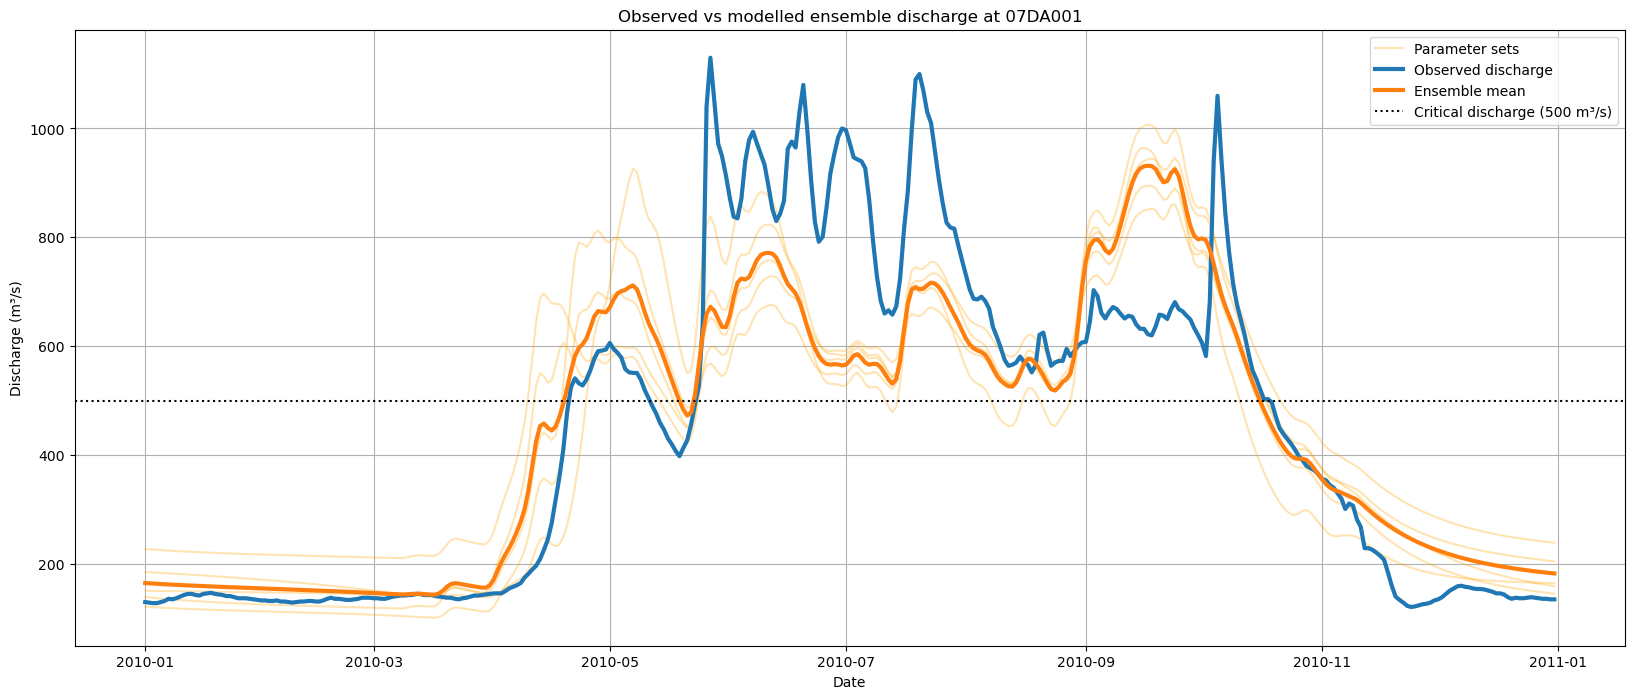

<Figure size 640x480 with 0 Axes>

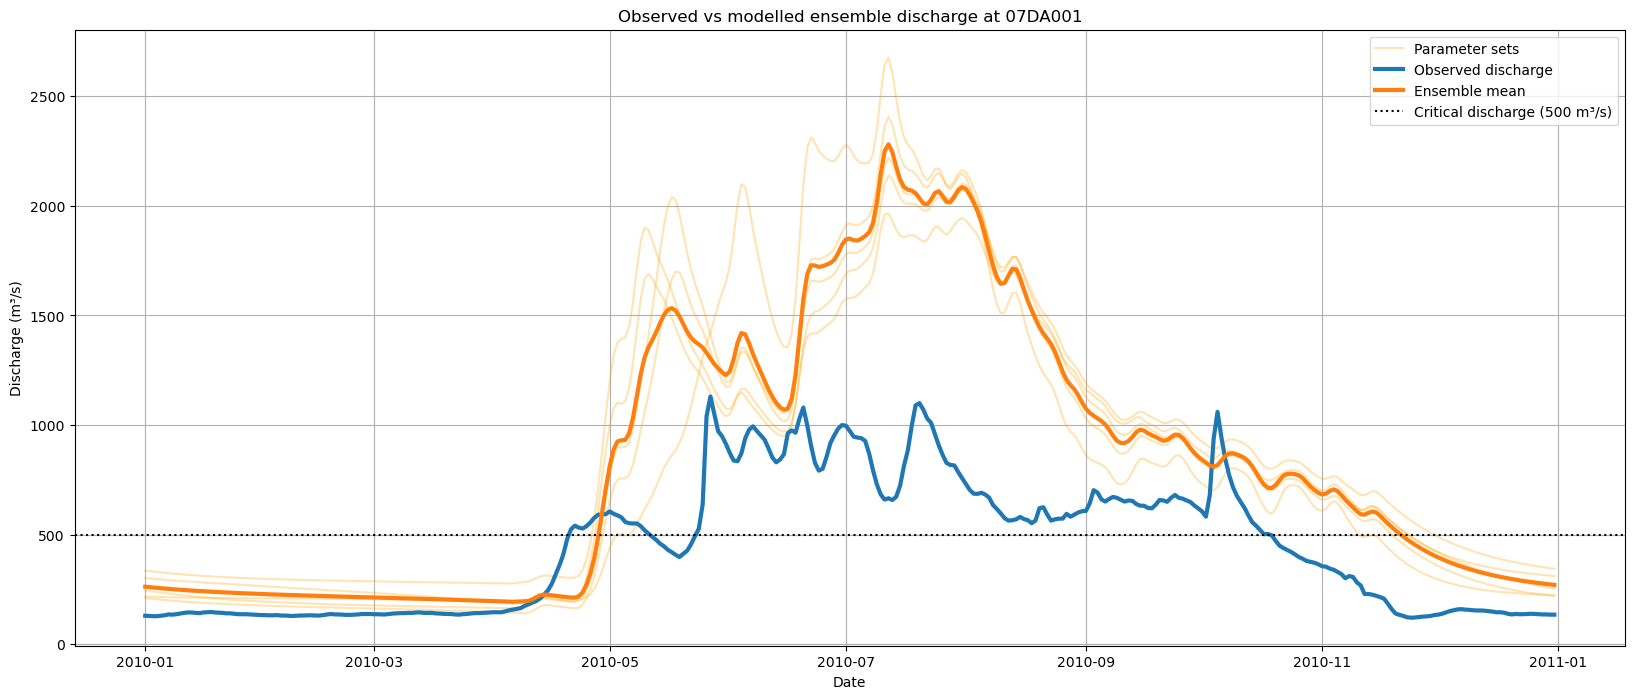

In [233]:
# Plot for selected year

selected_year = 2010

plot_ensemble(
    ensemble_data=ensemble_data_ERA5,
    plot_start=pd.to_datetime(f"{selected_year}-01-01"),
    plot_end=pd.to_datetime(f"{selected_year}-12-31")
)

plot_ensemble(
    ensemble_data=ensemble_data_CMIP,
    plot_start=pd.to_datetime(f"{selected_year}-01-01"),
    plot_end=pd.to_datetime(f"{selected_year}-12-31")
)

# plot_ensemble(
#     ensemble_data=ensemble_data_QDM,
#     plot_start=pd.to_datetime(f"{selected_year}-01-01"),
#     plot_end=pd.to_datetime(f"{selected_year}-12-31")
# )

## TEST - QDM

In [255]:
# Change observed and cmip to df

# Copy data 
cmip_mean = ensemble_data_CMIP["Mean"].copy()

# Change into df
cmip_mean_df = cmip_mean.to_frame(name="discharge")
observed_output_df = observed_output.to_frame(name="discharge")

# Select open water season period to exclude winter months from quantiles 
def select_open_water_season(series_or_df):

    data = series_or_df.copy()
    data.index = pd.to_datetime(data.index)

    mask = (((data.index.month > 5) & (data.index.month < 10)) | ((data.index.month == 5) & (data.index.day >= 18)) |((data.index.month == 10) & (data.index.day <= 17)))

    return data[mask]

observed_open = select_open_water_season(observed_output_df["discharge"])
cmip_open = select_open_water_season(cmip_mean_df["discharge"])

In [256]:
def quantile_mapping(observed, modelled, n):
    # Define a common quantile grid (e.g., 1000 points between 0 and 1)
    quantiles = np.linspace(0, 1, n)

    # Sort the data
    observed_sorted = np.sort(observed)
    modelled_sorted = np.sort(modelled)

    # Interpolate both series onto the common quantile grid
    observed_interpolated = interp1d(np.linspace(0, 1, len(observed_sorted)), observed_sorted, bounds_error=False, fill_value="extrapolate")
    modelled_interpolated = interp1d(np.linspace(0, 1, len(modelled_sorted)), modelled_sorted, bounds_error=False, fill_value="extrapolate")

    observed_on_quantiles = observed_interpolated(quantiles)
    modelled_on_quantiles = modelled_interpolated(quantiles)

    mapping_function = interp1d(modelled_on_quantiles, observed_on_quantiles, bounds_error=False, fill_value="extrapolate")

    return mapping_function

In [257]:
qm_daily = quantile_mapping(observed_open, cmip_open, 1000)
# qm_daily = quantile_mapping(observed_output_df["discharge"], cmip_mean_df["discharge"], 1000)

In [258]:
cmip_corrected_values = qm_daily(cmip_mean_df["discharge"])

cmip_mean_qm = pd.Series(cmip_corrected_values,index=cmip_mean_df.index,name="Mean")
cmip_mean_qm = cmip_mean_qm.fillna(0)
cmip_mean_qm = cmip_mean_qm.clip(lower=0)

# cmip_mean_qm.head()
# cmip_mean_qm.head(500)

ensemble_data_CMIP_QM = ensemble_data_CMIP.copy()
ensemble_data_CMIP_QM["Mean"] = cmip_mean_qm

ensemble_data_CMIP_QM.head(500)

,Set 1,Set 2,Set 3,Set 4,Set 5,Mean,Observed discharge
1995-01-02,0.000000,0.000000,0.000000,0.000000,0.000000,197.006634,196.0
1995-01-03,0.000000,0.000000,0.000000,0.000000,0.000000,197.006634,194.0
1995-01-04,0.000000,0.000000,0.000000,0.000000,0.000000,197.006634,191.0
1995-01-05,0.000000,0.000000,0.000000,0.000000,0.000000,197.006634,186.0
1995-01-06,0.000000,0.000000,0.000000,0.000000,0.000000,197.006634,180.0
...,...,...,...,...,...,...,...
1996-05-11,1200.499544,1578.823395,1934.690488,2360.785587,1667.775630,1500.000000,893.0
1996-05-12,1318.152547,1569.218431,1902.541667,2299.738496,1636.528975,1496.259269,860.0
1996-05-13,1448.767806,1570.017330,1893.828178,2270.186058,1622.187409,1503.762222,829.0
1996-05-14,1576.991892,1565.454242,1892.365134,2250.935805,1613.655879,1510.000000,804.0


<Figure size 640x480 with 0 Axes>

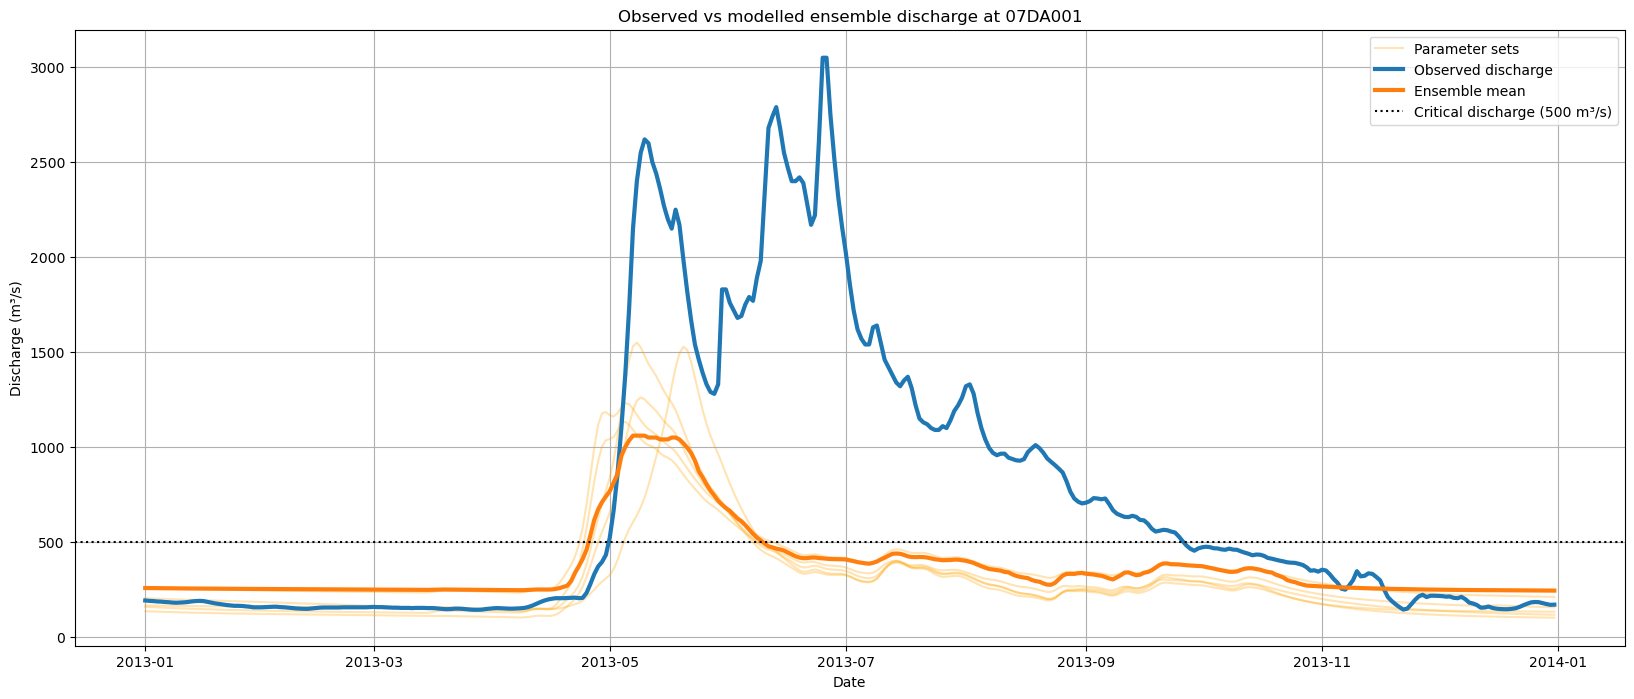

In [259]:
selected_year = 2013

plot_ensemble(
    ensemble_data=ensemble_data_CMIP_QM,
    plot_start=pd.to_datetime(f"{selected_year}-01-01"),
    plot_end=pd.to_datetime(f"{selected_year}-12-31")
)

In [67]:
# Qm_func = quantile_mapping(
#     observed=ensemble_data_ERA5, 
#     modelled=ensemble_data_CMIP, 
#     n=1000
# )

In [111]:
# Corrected = Qm_func(toekomstige data)

## 6. Lowflow calculation

In [69]:
def lowflow_counter_ensemble(ensemble_data, start_date, end_date):
    
    lowflow_days = []

    years = list(range(start_date.year, end_date.year + 1))

    for i in range(len(years)):
    
        year = years[i]
    
        # Define start and end month-day
        year_start = pd.to_datetime(f"{year}-05-18")
        year_end = pd.to_datetime(f"{year}-10-17")
    
        year_data = ensemble_data[
            (ensemble_data.index >= year_start) &
            (ensemble_data.index <= year_end)
        ]

        # Set zeros to count from
        observed_lowflow_days = 0
        modelled_lowflow_days = []
        modelmean_lowflow_days = 0

        # Count observed lowflow days
        for j in range(len(year_data)):
            observed_q = year_data.iloc[j]["Observed discharge"]

            if observed_q < q_critical:
                observed_lowflow_days += 1

        # Count model mean lowflow days
        for j in range(len(year_data)):
            modelmean_q = year_data.iloc[j]["Mean"]

            if modelmean_q < q_critical:
                modelmean_lowflow_days += 1

        # Count modelled lowflow days
        for j in range(len(par_ensemble)):
            set_lowflow_days = 0

            for k in range(len(year_data)):
                set_q = year_data.iloc[k][f"Set {j+1}"]

                if set_q < q_critical:
                    set_lowflow_days += 1

            modelled_lowflow_days.append(set_lowflow_days)

        setavg_lowflow_days = np.mean(modelled_lowflow_days)
        
        lowflow_days.append({
            "year": year,
            "observed": observed_lowflow_days,
            "modelmean": modelmean_lowflow_days,
            "set_1": modelled_lowflow_days[0],
            "set_2": modelled_lowflow_days[1],
            "set_3": modelled_lowflow_days[2],
            "set_4": modelled_lowflow_days[3],
            "set_5": modelled_lowflow_days[4],
            "set_avg": np.round(setavg_lowflow_days)
        })

    lowflow_days = pd.DataFrame(lowflow_days)

    days_sum = lowflow_days[["observed", "modelmean", "set_1", "set_2", "set_3", "set_4", "set_5", "set_avg"]].sum()

    print(days_sum)

    return lowflow_days

In [99]:
lowflow_ERA5 = lowflow_counter_ensemble(
    ensemble_data=ensemble_data_ERA5,
    start_date=evaluation_start,
    end_date=validation_end_date
)

lowflow_CMIP = lowflow_counter_ensemble(
    ensemble_data=ensemble_data_CMIP,
    start_date=evaluation_start,
    end_date=validation_end_date
)

# lowflow_QDM = lowflow_counter_ensemble(
#     ensemble_data=ensemble_data_CMIP_corrected,
#     start_date=evaluation_start,
#     end_date=validation_end_date
# )

lowflow_CMIP

observed     488.0
modelmean    494.0
set_1        659.0
set_2        489.0
set_3        485.0
set_4        439.0
set_5        423.0
set_avg      498.0
dtype: float64

observed     532.0
modelmean    538.0
set_1        711.0
set_2        464.0
set_3        546.0
set_4        558.0
set_5        376.0
set_avg      532.0
dtype: float64

observed     532.0
modelmean    770.0
set_1        946.0
set_2        769.0
set_3        772.0
set_4        716.0
set_5        671.0
set_avg      776.0
dtype: float64

,year,observed,modelmean,set_1,set_2,set_3,set_4,set_5,set_avg
0,1996,0,110,111,100,99,101,113,105.0
1,1997,0,38,52,34,36,39,35,39.0
2,1998,44,6,11,0,5,2,0,4.0
3,1999,35,20,39,7,21,24,2,19.0
4,2000,20,29,36,26,29,29,22,28.0
5,2001,60,0,0,0,0,0,0,0.0
6,2002,52,0,8,0,0,0,0,2.0
7,2003,51,6,21,0,7,9,0,7.0
8,2004,5,23,41,17,27,31,0,23.0
9,2005,0,0,0,0,0,0,0,0.0


## 7. Cumsum

In [112]:
def rank(lowflow_ERA5, lowflow_CMIP, lowflow_QDM):

    # Combine tables
    rank_table = pd.DataFrame({
        "Observed": np.sort(lowflow_ERA5["observed"]),
        "ERA5": np.sort(lowflow_ERA5["set_avg"]),
        "CMIP6": np.sort(lowflow_CMIP["set_avg"]),
        # "QDM": np.sort(lowflow_QDM["set_avg"])
    })
    
    rank_table.insert(0, "rank", range(1, len(rank_table) + 1))

    return rank_table

In [113]:
rank_table = rank(lowflow_ERA5, lowflow_CMIP, lowflow_QDM)
# rank_table = rank(lowflow_ERA5, lowflow_CMIP)

rank_table

,rank,Observed,ERA5,CMIP6
0,1,0,0.0,0.0
1,2,0,0.0,0.0
2,3,0,0.0,0.0
3,4,0,0.0,2.0
4,5,5,1.0,2.0
5,6,6,2.0,4.0
6,7,13,5.0,4.0
7,8,20,10.0,7.0
8,9,21,17.0,12.0
9,10,25,19.0,19.0


In [114]:
cumsum_table = pd.DataFrame({
    "Observed_cumsum": rank_table["Observed"].cumsum(),
     "ERA5_cumsum": rank_table["ERA5"].cumsum(),
    "CMIP6_cumsum": rank_table["CMIP6"].cumsum(),
    # "QDM_cumsum": rank_table["QDM"].cumsum()
})

cumsum_table

,Observed_cumsum,ERA5_cumsum,CMIP6_cumsum
0,0,0.0,0.0
1,0,0.0,0.0
2,0,0.0,0.0
3,0,0.0,2.0
4,5,1.0,4.0
5,11,3.0,8.0
6,24,8.0,12.0
7,44,18.0,19.0
8,65,35.0,31.0
9,90,54.0,50.0


In [115]:
def plot_cumsum(rank_table):

    plt.figure(figsize=(8, 5))

    # Plot cumsum for all columns, skipping rank column
    for i in range(1, len(rank_table.columns)):
        plt.plot(
            rank_table["rank"],
            rank_table[rank_table.columns[i]].cumsum(),
            marker="o",
            label=rank_table.columns[i]
        )

    # Plotting
    plt.xlabel("Ranked years")
    plt.ylabel("Cumulative low flow days")
    plt.xticks(rank_table["rank"])
    plt.title("Cumulative annual low flow days")
    # plt.grid(True)
    plt.legend()
    plt.show()

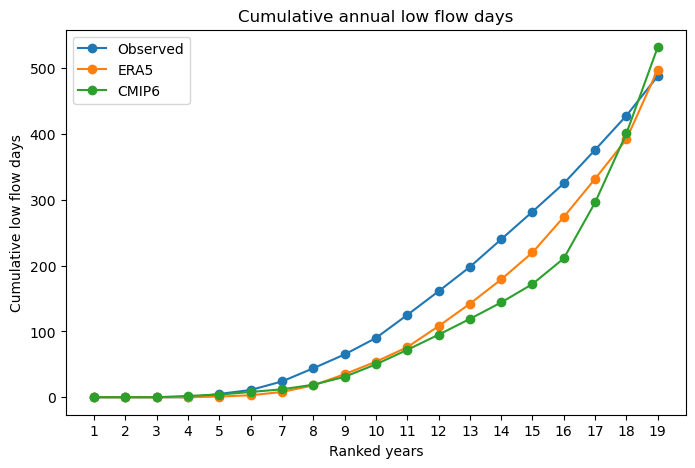

In [116]:
plot_cumsum(rank_table)

## 8. Quantile Mapping

In [105]:
def quantile_mapping(observed, modelled, n):
    # Define a common quantile grid (e.g., 1000 points between 0 and 1)
    quantiles = np.linspace(0, 1, n)

    # Sort the data
    observed_sorted = np.sort(observed)
    modelled_sorted = np.sort(modelled)

    # Interpolate both series onto the common quantile grid
    observed_interpolated = interp1d(np.linspace(0, 1, len(observed_sorted)), observed_sorted, bounds_error=False, fill_value="extrapolate")
    modelled_interpolated = interp1d(np.linspace(0, 1, len(modelled_sorted)), modelled_sorted, bounds_error=False, fill_value="extrapolate")

    observed_on_quantiles = observed_interpolated(quantiles)
    modelled_on_quantiles = modelled_interpolated(quantiles)

    # Create mapping from modelled deficits to observed using interpolation
    mapping_function = interp1d(modelled_on_quantiles, observed_on_quantiles, bounds_error=False, fill_value="extrapolate")

    return mapping_function

In [107]:
def correct_discharge_ensemble(ensemble_data, reference_data, start_date, end_date, n=1000):

    corrected_data = pd.DataFrame(index=ensemble_data.index)

    # Prepare CMIP data
    target = ensemble_data.copy()
    target.index = pd.to_datetime(target.index).tz_localize(None).normalize()

    # Prepare ERA5 reference
    reference = reference_data.copy()
    reference.index = pd.to_datetime(reference.index).tz_localize(None).normalize()

    # Select calibration period
    start_date = pd.to_datetime(start_date).tz_localize(None).normalize()
    end_date = pd.to_datetime(end_date).tz_localize(None).normalize()

    target_period = target[(target.index >= start_date) &(target.index <= end_date)]
    reference_period = reference[(reference.index >= start_date) &(reference.index <= end_date)]

    # Correct each parameter set separately
    for i in range(len(par_ensemble)):

        set_name = f"Set {i+1}"

        qm_function = quantile_mapping(
            observed=reference_period[set_name],
            modelled=target_period[set_name],
            n=n
        )

        corrected_data[set_name] = qm_function(target[set_name])

    # Remove negative discharge
    corrected_data[corrected_data < 0] = 0

    # Recalculate ensemble mean from corrected sets
    corrected_data["Mean"] = corrected_data.mean(axis=1)
    # set_columns = [f"Set {i+1}" for i in range(len(par_ensemble))]
    # corrected_data["Mean"] = corrected_data[set_columns].mean(axis=1)

    # Keep observed discharge if present
    if "Observed discharge" in target.columns:
        corrected_data["Observed discharge"] = target["Observed discharge"]

    return corrected_data

In [109]:
ensemble_data_CMIP_corrected = correct_discharge_ensemble(
    ensemble_data=ensemble_data_CMIP,
    reference_data=ensemble_data_ERA5,
    start_date=evaluation_start,
    end_date=validation_end_date,
    n=1000
)

ensemble_data_CMIP_corrected.head()

,Set 1,Set 2,Set 3,Set 4,Set 5,Mean,Observed discharge
1995-01-02,0.0,0.0,0.0,0.0,0.0,0.0,196.0
1995-01-03,0.0,0.0,0.0,0.0,0.0,0.0,194.0
1995-01-04,0.0,0.0,0.0,0.0,0.0,0.0,191.0
1995-01-05,0.0,0.0,0.0,0.0,0.0,0.0,186.0
1995-01-06,0.0,0.0,0.0,0.0,0.0,0.0,180.0


In [110]:
lowflow_CMIP_corrected = lowflow_counter_ensemble(
    ensemble_data=ensemble_data_CMIP_corrected,
    start_date=evaluation_start,
    end_date=validation_end_date
)

lowflow_CMIP_corrected

observed     532.0
modelmean    770.0
set_1        946.0
set_2        769.0
set_3        772.0
set_4        716.0
set_5        671.0
set_avg      776.0
dtype: float64

,year,observed,modelmean,set_1,set_2,set_3,set_4,set_5,set_avg
0,1996,0,119,119,118,115,118,125,119.0
1,1997,0,46,56,42,41,43,45,45.0
2,1998,44,11,20,10,10,8,10,12.0
3,1999,35,49,56,48,49,44,41,48.0
4,2000,20,36,47,35,35,34,33,37.0
5,2001,60,0,8,0,0,0,0,2.0
6,2002,52,3,17,1,4,1,0,5.0
7,2003,51,38,54,44,44,20,12,35.0
8,2004,5,59,70,63,64,49,37,57.0
9,2005,0,0,6,0,0,0,0,1.0
